In [ ]:
# ============================================================
# 0. CÀI ĐẶT THƯ VIỆN
# ============================================================

import subprocess
import sys

def pip_install(*packages):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *packages]
    )

print("Installing PennyLane...")

# Chỉ cài PennyLane mới nhất tương thích với môi trường hiện tại
pip_install("-U", "pennylane")

print("Done!")
!pip install pennylane-lightning[gpu]

Installing PennyLane...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 120.3 MB/s eta 0:00:00
Done!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.6/924.6 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 26.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pennylane as qml

print(np.__version__)
print(qml.__version__)

2.0.2
0.45.1


In [ ]:
import pennylane as qml
import torch

print("PennyLane:", qml.__version__)
print("Torch:", torch.__version__)

PennyLane: 0.45.1
Torch: 2.10.0+cu128


In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import os
import random
from collections import Counter

import pandas as pd
import numpy as np
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
!pip install -q ultralytics
import pennylane as qml
from ultralytics import YOLO

# Cấu hình GPU của Kaggle
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Đang sử dụng thiết bị (Device): {DEVICE}")
if DEVICE == "cuda":
    print("   GPU Name:", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Đang sử dụng thiết bị (Device): cuda
   GPU Name: Tesla T4


In [ ]:
# ============================================================
# 2. CẤU HÌNH THAM SỐ HUẤN LUYỆN HQNN (Sử dụng 4 Qubits)
# ============================================================
DATASET_PATH = Path("/kaggle/input/datasets/abcnexttt/data-after-handle/data_convert_yolo_format")
WORK_DIR     = Path("/kaggle/working")
HQNN_CROPS_DIR = WORK_DIR / "hqnn_crops"

# YOLO weights dùng để crop ROI tự động (cung cấp trong input Kaggle)
YOLO_PRETRAINED_WEIGHTS = Path("/kaggle/input/models/abcnexttt/yolov12n-/other/default/1/best.pt")

CLASS_NAMES = ["Broken", "Chipped", "Scratched", "Severe_Rust", "Tip_Wear"]
NUM_CLASSES  = len(CLASS_NAMES)

# Tham số HQNN chạy trên Kaggle GPU (Chỉnh sửa về 4 Qubits và ROI 224)
HQNN_EPOCHS    = 110
HQNN_BATCH     = 32
HQNN_LR        = 1e-3
N_QUBITS       = 4        # Sử dụng 4 qubits theo đúng thiết kế của bài báo
N_LAYERS       = 3
HQNN_IMG_SIZE  = 224      # ROI kích thước 224x224 theo sơ đồ

HQNN_CROPS_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Cấu hình hoàn tất! Đã cập nhật N_QUBITS = 4 và HQNN_IMG_SIZE = 224")


✅ Cấu hình hoàn tất! Đã cập nhật N_QUBITS = 4 và HQNN_IMG_SIZE = 224


# 3. Định nghĩa kiến trúc HQNN Classifier (Chạy trên GPU, 4 Qubits)

Thiết bị lượng tử mô phỏng sử dụng đúng 4 qubits để mã hóa 4 chiều đặc trưng được trích xuất từ CNN.


In [ ]:
# ============================================================
# ĐỊNH NGHĨA MÔ HÌNH LAI LƯỢNG TỬ (HQNN - 4 QUBITS)
# ============================================================

# Sử dụng default.qubit với interface='torch'. Khi ta chuyển mô hình và dữ liệu đầu vào lên GPU, 
# PyTorch và PennyLane sẽ phối hợp thực hiện tính toán lan truyền ngược tự động trên GPU.
quantum_device = qml.device("lightning.gpu", wires=N_QUBITS)

@qml.qnode(quantum_device, interface="torch")
def quantum_circuit(inputs, weights):
    # Bước 4: Hadamard Gate (Khởi tạo superposition trên 4 qubits)
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)

    # Angle Encoding (RY) chuyển đổi Feature Vector thành góc quay
    for i in range(N_QUBITS):
        qml.RY(inputs[..., i], wires=i)

    # Bước 5: Parameterized Entanglement Layer (CNOT) cho 4 Qubits
    for layer in range(N_LAYERS):
        # CNOT liên kết chuỗi đan xen dạng Ring giữa 4 qubits
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
        
        # Các cổng xoay lượng tử được huấn luyện tham số
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i], wires=i)

    # Đo trạng thái đầu ra PauliZ của 4 qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


class HQNNClassifier(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        # Bước 3: Classical CNN Feature Extractor nhận ROI 224x224x3
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d((2, 2))  # -> (64, 2, 2)
        
        # Rút trích Feature Vector 4-dim (Mã hóa vào 4 Qubits)
        self.fc_encode = nn.Sequential(
            nn.Linear(64 * 2 * 2, N_QUBITS),
            nn.Tanh(),
        )

        weight_shapes = {"weights": (N_LAYERS, N_QUBITS)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Lớp Quantum FC Post-processing (Linear + Tanh)
        self.quantum_fc = nn.Sequential(
            nn.Linear(N_QUBITS, N_QUBITS),
            nn.Tanh(),
        )
        
        self.classifier = nn.Linear(N_QUBITS, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc_encode(x)
        
        # Ánh xạ đặc trưng thuộc [0, pi] cho Angle Encoding
        x = (x + 1.0) * (torch.pi / 2.0)
        
        # Tính toán lượng tử (4 qubits)
        x = self.quantum_layer(x)
        
        # Tiền xử lý sau lượng tử & Phân lớp
        x = self.quantum_fc(x)
        x = self.classifier(x)
        return x


# Kiểm thử khởi tạo mô hình trên GPU với 4 Qubits
model_test = HQNNClassifier(NUM_CLASSES).to(DEVICE)
dummy_x = torch.randn(2, 3, HQNN_IMG_SIZE, HQNN_IMG_SIZE).to(DEVICE)
print("✅ Khởi tạo mô hình 4 Qubits thành công. Kích thước output:", model_test(dummy_x).shape)


✅ Khởi tạo mô hình 4 Qubits thành công. Kích thước output: torch.Size([2, 5])


# 4. Trích xuất ROI từ YOLO đã train (kích thước 224x224)

In [ ]:
# ============================================================
# TRÍCH XUẤT CROP ROI 224x224
# ============================================================

def extract_hqnn_crops(yolo_model_path, split="train", conf=0.25, max_per_class=500):
    if not Path(yolo_model_path).exists():
        print(f"⚠️ Không tìm thấy file weights YOLO tại {yolo_model_path}.")
        return {}
        
    detector = YOLO(str(yolo_model_path))
    out_dir  = HQNN_CROPS_DIR / split
    for cls_name in CLASS_NAMES:
        (out_dir / cls_name).mkdir(parents=True, exist_ok=True)

    img_dir   = DATASET_PATH / split / "images"
    label_dir = DATASET_PATH / split / "labels"
    if not img_dir.exists():
        return {}
        
    img_files = sorted(img_dir.glob("*.jpg")) + sorted(img_dir.glob("*.png"))

    counts = Counter()
    for img_path in img_files:
        label_path = label_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id  = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])

            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            if x2 <= x1 or y2 <= y1:
                continue
            if counts[cls_id] >= max_per_class:
                continue

            crop = img[y1:y2, x1:x2]
            crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            save_name = f"{img_path.stem}_{x1}_{y1}.jpg"
            save_path = out_dir / CLASS_NAMES[cls_id] / save_name
            
            crop_resized = cv2.resize(crop_rgb, (HQNN_IMG_SIZE, HQNN_IMG_SIZE))
            cv2.imwrite(str(save_path), cv2.cvtColor(crop_resized, cv2.COLOR_RGB2BGR))
            counts[cls_id] += 1

    print(f"\n✅ Đã trích xuất và resize ROI (size={HQNN_IMG_SIZE}) thành công:")
    for cid, cnt in sorted(counts.items()):
        print(f"   [{cid}] {CLASS_NAMES[cid]:12s}: {cnt} crops")
    return counts

# Thực hiện trích xuất dữ liệu huấn luyện lượng tử
_ = extract_hqnn_crops(YOLO_PRETRAINED_WEIGHTS, split="train", max_per_class=1200)
_ = extract_hqnn_crops(YOLO_PRETRAINED_WEIGHTS, split="valid",   max_per_class=400)



✅ Đã trích xuất và resize ROI (size=224) thành công:
   [0] Broken      : 747 crops
   [1] Chipped     : 1134 crops
   [2] Scratched   : 1200 crops
   [3] Severe_Rust : 1200 crops
   [4] Tip_Wear    : 907 crops

✅ Đã trích xuất và resize ROI (size=224) thành công:
   [0] Broken      : 170 crops
   [1] Chipped     : 162 crops
   [2] Scratched   : 217 crops
   [3] Severe_Rust : 210 crops
   [4] Tip_Wear    : 200 crops


# 5. Dataset & DataLoader cho HQNN

In [ ]:
class CropDataset(Dataset):
    def __init__(self, root_dir, img_size=HQNN_IMG_SIZE, augment=False):
        self.samples = []
        self.img_size = img_size
        self.augment  = augment

        for cls_id, cls_name in enumerate(CLASS_NAMES):
            cls_dir = Path(root_dir) / cls_name
            if not cls_dir.exists():
                continue
            for p in cls_dir.glob("*.jpg"):
                self.samples.append((p, cls_id))
            for p in cls_dir.glob("*.png"):
                self.samples.append((p, cls_id))

        random.shuffle(self.samples)

        self.base_tf = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.aug_tf = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cls_id = self.samples[idx]
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tf  = self.aug_tf if self.augment else self.base_tf
        return tf(img), cls_id


train_dataset = CropDataset(HQNN_CROPS_DIR / "train", augment=True)
val_dataset   = CropDataset(HQNN_CROPS_DIR / "valid",   augment=False)

train_loader = DataLoader(train_dataset, batch_size=HQNN_BATCH, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=HQNN_BATCH, shuffle=False, num_workers=2, pin_memory=True)


# 6. Huấn Luyện HQNN (4 Qubits) trên GPU

In [ ]:
# ============================================================
# HUẤN LUYỆN MÔ HÌNH LAI LƯỢNG TỬ
# ============================================================
hqnn_model = HQNNClassifier(num_classes=NUM_CLASSES).to(DEVICE)
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(hqnn_model.parameters(), lr=HQNN_LR)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HQNN_EPOCHS)

HQNN_SAVE_PATH = WORK_DIR / "hqnn_best.pt"

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

print(f"🚀 Bắt đầu huấn luyện mô hình 4 qubits trên thiết bị: {DEVICE}...")
print(f"Số lượng Epochs: {HQNN_EPOCHS} | Batch Size: {HQNN_BATCH} | Tỷ lệ học: {HQNN_LR}")
print("-" * 80)

for epoch in range(1, HQNN_EPOCHS + 1):
    # Phase Huấn luyện
    hqnn_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        logits = hqnn_model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        train_loss    += loss.item() * images.size(0)
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total   += images.size(0)

    # Phase Đánh giá (Validation)
    hqnn_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = hqnn_model(images)
            loss   = criterion(logits, labels)
            
            val_loss    += loss.item() * images.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += images.size(0)

    scheduler.step()

    t_loss = train_loss / train_total if train_total > 0 else 0
    t_acc  = train_correct / train_total if train_total > 0 else 0
    v_loss = val_loss / val_total if val_total > 0 else 0
    v_acc  = val_correct / val_total if val_total > 0 else 0

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    # Lưu trữ weights tối ưu nhất dựa trên độ chính xác tập val
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save({
            "epoch"       : epoch,
            "model_state" : hqnn_model.state_dict(),
            "val_acc"     : v_acc,
        }, str(HQNN_SAVE_PATH))

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:3d}/{HQNN_EPOCHS}] Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f} {'⭐️' if v_acc == best_val_acc else ''}")

print(f"\n✅ Đã huấn luyện xong! Độ chính xác tối ưu đạt được: {best_val_acc:.4f}")
print("Mô hình tối ưu lưu tại:", HQNN_SAVE_PATH)


🚀 Bắt đầu huấn luyện mô hình 4 qubits trên thiết bị: cuda...
Số lượng Epochs: 110 | Batch Size: 32 | Tỷ lệ học: 0.001
--------------------------------------------------------------------------------
Epoch [  1/110] Train Loss: 1.5766 Acc: 0.2502 | Val Loss: 1.4495 Acc: 0.4682 ⭐️
Epoch [  5/110] Train Loss: 1.0879 Acc: 0.5765 | Val Loss: 1.3651 Acc: 0.4807 
Epoch [ 10/110] Train Loss: 0.8556 Acc: 0.6665 | Val Loss: 1.3728 Acc: 0.4745 
Epoch [ 15/110] Train Loss: 0.7657 Acc: 0.7113 | Val Loss: 1.7651 Acc: 0.4526 
Epoch [ 20/110] Train Loss: 0.6968 Acc: 0.7396 | Val Loss: 0.9998 Acc: 0.6184 
Epoch [ 25/110] Train Loss: 0.6432 Acc: 0.7487 | Val Loss: 1.7690 Acc: 0.4849 
Epoch [ 30/110] Train Loss: 0.6029 Acc: 0.7679 | Val Loss: 0.6784 Acc: 0.7268 
Epoch [ 35/110] Train Loss: 0.5506 Acc: 0.7959 | Val Loss: 0.7844 Acc: 0.7351 
Epoch [ 40/110] Train Loss: 0.5292 Acc: 0.8040 | Val Loss: 0.6746 Acc: 0.7445 
Epoch [ 45/110] Train Loss: 0.4936 Acc: 0.8190 | Val Loss: 0.8839 Acc: 0.6757 
Epoch [ 5

# 7. Visualize Tiến trình huấn luyện HQNN

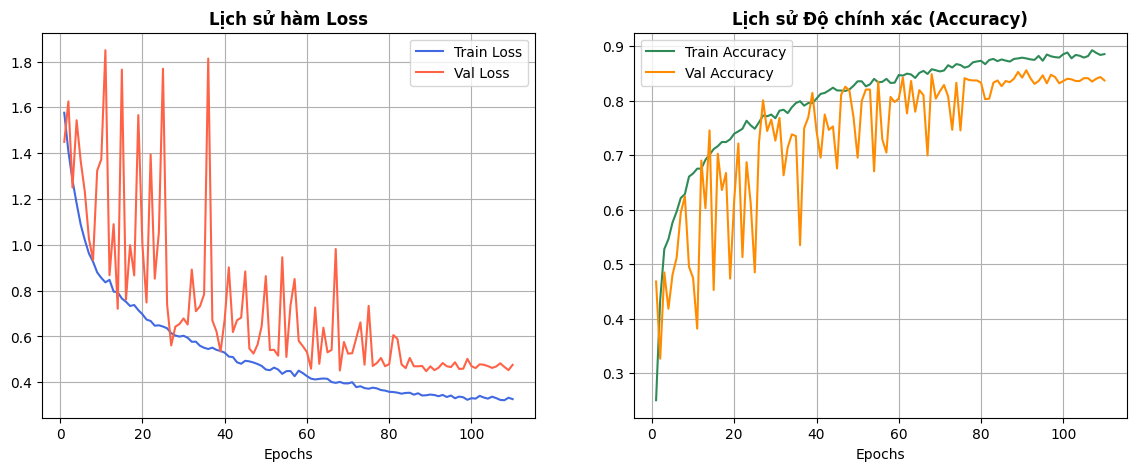

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

# Biểu đồ Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color="royalblue")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", color="tomato")
axes[0].set_title("Lịch sử hàm Loss", fontweight="bold")
axes[0].set_xlabel("Epochs")
axes[0].legend()
axes[0].grid(True)

# Biểu đồ Accuracy
axes[1].plot(epochs_range, history["train_acc"], label="Train Accuracy", color="seagreen")
axes[1].plot(epochs_range, history["val_acc"], label="Val Accuracy", color="darkorange")
axes[1].set_title("Lịch sử Độ chính xác (Accuracy)", fontweight="bold")
axes[1].set_xlabel("Epochs")
axes[1].legend()
axes[1].grid(True)

plt.show()
